# 04 — Phase 4: Model Comparison, Sequence Models & Artifacts


## 1 — Bootstrap


In [2]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
SRC = ROOT / 'src'
assert SRC.exists(), f'Could not find src/ at {SRC}'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from dataset import build_dataset
from stationary import add_stationary_features, get_stationary_features
from targets import build_directional_dataset
from modeling import (build_model, compare_models, evaluate_across_offsets,
                      evaluate_across_seeds, list_models)
from abstention import coverage_accuracy_curve

config.ensure_dirs()
pd.set_option('display.width', 150)
plt.rcParams['figure.dpi'] = 110

BASE = {}
for key in config.list_stocks():
    d = build_dataset(key, with_sentiment=False, save=False, verbose=False)
    BASE[key] = add_stationary_features(d).dropna().reset_index(drop=True)
    print(f'{key:10s} {len(BASE[key]):5d} rows')

FEATURES = get_stationary_features(BASE['TCS'])
print(f'\nfeatures: {len(FEATURES)}   models: {list_models()}')


RELIANCE     383 rows
TCS         2354 rows

features: 52   models: ['dummy', 'gradient_boosting', 'logistic', 'random_forest']


## 2 — Install PyTorch


In [2]:
%pip install -q torch

try:
    import torch
    print(f'torch {torch.__version__} ready')
except ImportError:
    print('torch not available — section 6 will be skipped')


Note: you may need to restart the kernel to use updated packages.
torch 2.13.0+cpu ready


## 3 — Model comparison


In [3]:
CONFIG = dict(horizon=3, k=0.0, non_overlapping=True)
EVAL = dict(n_splits=5, embargo=17)

MODEL_TABLES = {}
for key, d in BASE.items():
    ds = build_directional_dataset(d, **CONFIG)
    if len(ds) < 200:
        print(f'{key}: only {len(ds)} rows at horizon 3 — skipping')
        continue
    print(f'\n{key}  (n={len(ds)})')
    table, results = compare_models(ds, FEATURES, seeds=(0, 1, 7, 42, 99,
                                                          123, 2024),
                                    verbose=False, **EVAL)
    MODEL_TABLES[key] = table
    print(table.to_string())


RELIANCE: only 123 rows at horizon 3 — skipping

TCS  (n=780)
                   mean_accuracy  seed_std  mean_edge  min_edge  max_edge  baseline  n_seeds  deterministic  all_seeds_positive  offsets_tested                      verdict
model                                                                                                                                                                       
gradient_boosting         0.5462    0.0000     0.0282    0.0282    0.0282    0.5179        7          False                True           False  POSITIVE (offsets untested)
random_forest             0.5366    0.0107     0.0187    0.0051    0.0385    0.5179        7          False                True           False  POSITIVE (offsets untested)
logistic                  0.5333    0.0000     0.0154    0.0154    0.0154    0.5179        7          False                True           False  POSITIVE (offsets untested)
dummy                     0.5029    0.0266    -0.0150   -0.0641    0.0308

## 4 — Seed sensitivity


In [4]:
ds = build_directional_dataset(BASE['TCS'], **CONFIG)

seed_rows = []
for name in ['random_forest', 'gradient_boosting', 'logistic']:
    r = evaluate_across_seeds(ds, FEATURES, name, **EVAL)
    for seed, acc, edge in zip(r.seeds, r.accuracies, r.edges):
        seed_rows.append({'model': name, 'seed': seed,
                          'accuracy': round(acc, 4), 'edge': round(edge, 4)})

seed_df = pd.DataFrame(seed_rows)
print(seed_df.pivot(index='seed', columns='model', values='edge').to_string())
print()
print(seed_df.groupby('model')['edge'].agg(['mean', 'std', 'min', 'max'])
      .round(4).to_string())


model  gradient_boosting  logistic  random_forest
seed                                             
0                 0.0282    0.0154         0.0231
1                 0.0282    0.0154         0.0256
7                 0.0282    0.0154         0.0051
42                0.0282    0.0154         0.0385
99                0.0282    0.0154         0.0128
123               0.0282    0.0154         0.0077
2024              0.0282    0.0154         0.0179

                     mean     std     min     max
model                                            
gradient_boosting  0.0282  0.0000  0.0282  0.0282
logistic           0.0154  0.0000  0.0154  0.0154
random_forest      0.0187  0.0115  0.0051  0.0385


## 5 — Offset sensitivity


In [5]:
def builder(frame, offset):
    return build_directional_dataset(frame.iloc[offset:].reset_index(drop=True),
                                     **CONFIG)

offset_rows = []
for name in ['random_forest', 'gradient_boosting', 'logistic']:
    offs, edges = evaluate_across_offsets(BASE['TCS'], FEATURES, name,
                                          dataset_builder=builder,
                                          n_offsets=CONFIG['horizon'],
                                          **EVAL)
    for o, e in zip(offs, edges):
        offset_rows.append({'model': name, 'offset': o, 'edge': round(e, 4)})

offset_df = pd.DataFrame(offset_rows)
print(offset_df.pivot(index='offset', columns='model', values='edge')
      .to_string())
print()
print('All offsets positive?')
print(offset_df.groupby('model')['edge'].apply(lambda s: bool((s > 0).all()))
      .to_string())


model   gradient_boosting  logistic  random_forest
offset                                            
0                  0.0282    0.0154         0.0385
1                  0.0385    0.0333         0.0333
2                 -0.0385    0.0103        -0.0128

All offsets positive?
model
gradient_boosting    False
logistic              True
random_forest        False


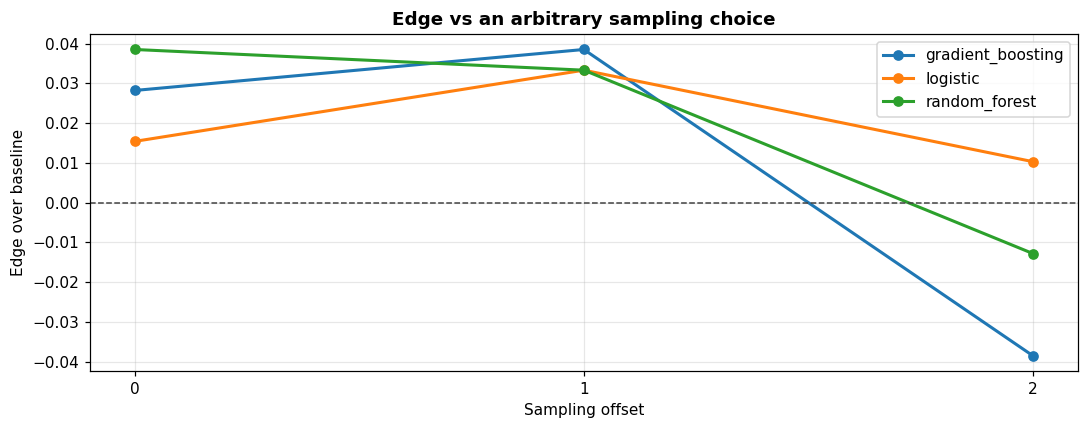

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for name, grp in offset_df.groupby('model'):
    ax.plot(grp['offset'], grp['edge'], 'o-', lw=2, label=name)
ax.axhline(0, color='#424242', lw=1, ls='--')
ax.set_xlabel('Sampling offset')
ax.set_ylabel('Edge over baseline')
ax.set_xticks(range(CONFIG['horizon']))
ax.set_title('Edge vs an arbitrary sampling choice', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'phase4_offset_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6 — Real LSTM and GRU


In [7]:
from sequence_models import TORCH_AVAILABLE, compare_sequence_models

SEQ_TABLES = {}
if TORCH_AVAILABLE:
    for key, d in BASE.items():
        returns = d['Close'].pct_change().dropna()
        if len(returns) < 300:
            print(f'{key}: too few returns — skipping')
            continue
        print(f'\n{key}  (n={len(returns)})')
        table, _ = compare_sequence_models(returns, seeds=(0, 42, 123),
                                           epochs=30, verbose=False)
        SEQ_TABLES[key] = table
        print(table.to_string())
else:
    print('torch unavailable — run section 2')



RELIANCE  (n=382)
       rmse_mean  rmse_std  directional_mean  persistence_rmse  zero_rmse  beats_persistence  beats_zero  shrinkage
model                                                                                                              
LSTM    0.009109  0.000026            0.5022          0.012354    0.00893               True       False     0.1849
GRU     0.009133  0.000078            0.5065          0.012354    0.00893               True       False     0.1926

TCS  (n=2353)
       rmse_mean  rmse_std  directional_mean  persistence_rmse  zero_rmse  beats_persistence  beats_zero  shrinkage
model                                                                                                              
LSTM    0.013117  0.000004            0.4933          0.018418   0.013069               True       False     0.0962
GRU     0.013248  0.000120            0.5124          0.018418   0.013069               True       False     0.1196


## 7 — Are the sequence models predicting anything?


model                       LSTM
rmse                    0.013121
mae                     0.009574
directional_accuracy      0.4862
persistence_rmse        0.018418
zero_rmse               0.013069
beats_persistence           True
beats_zero                 False
prediction_shrinkage      0.0889
n_train                     1852
n_test                       471

NO SIGNAL - worse than predicting zero; the model has collapsed toward a constant.


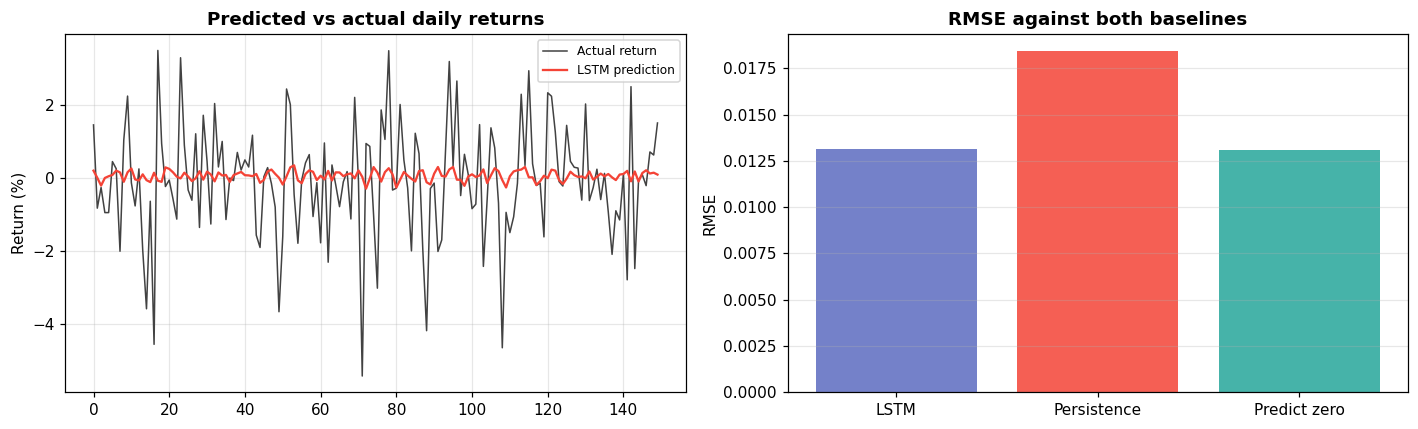

In [8]:
if TORCH_AVAILABLE:
    from sequence_models import train_sequence_model

    res = train_sequence_model(BASE['TCS']['Close'].pct_change().dropna(),
                               cell='lstm', epochs=30, random_state=42)
    print(pd.Series(res.summary()).to_string())
    print()
    print(res.verdict())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(res.y_true[:150] * 100, color='#424242', lw=1,
                 label='Actual return')
    axes[0].plot(res.y_pred[:150] * 100, color='#F44336', lw=1.5,
                 label='LSTM prediction')
    axes[0].set_ylabel('Return (%)')
    axes[0].set_title('Predicted vs actual daily returns', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    bars = ['LSTM', 'Persistence', 'Predict zero']
    vals = [res.rmse, res.persistence_rmse, res.zero_rmse]
    cols = ['#5C6BC0', '#F44336', '#26A69A']
    axes[1].bar(bars, vals, color=cols, alpha=0.85)
    axes[1].set_ylabel('RMSE')
    axes[1].set_title('RMSE against both baselines', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / 'phase4_sequence_models.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## 8 — Train and save artifacts


In [1]:
from pipeline import TrainConfig, train_all

cfg = TrainConfig(model_name='logistic', horizon=3, k=0.0,
                  non_overlapping=True, n_splits=5, embargo=17)

ARTIFACTS = train_all(cfg=cfg)


ModuleNotFoundError: No module named 'pipeline'

## 9 — Verify saved artifacts


In [10]:
import json
from pipeline import artifacts_exist, load_artifacts, predict_latest

rows = []
for key in config.list_stocks():
    if not artifacts_exist(key):
        print(f'{key}: NO ARTIFACTS')
        continue
    art = load_artifacts(key)
    m = art['metadata']
    pred = predict_latest(key)
    rows.append({
        'stock': key,
        'horizon': m['config']['horizon'],
        'rows': m['n_modelling_rows'],
        'accuracy': m['walk_forward_accuracy'],
        'baseline': m['baseline'],
        'edge': m['edge'],
        'permutation': (m['permutation'] or {}).get('verdict'),
        'seed_verdict': (m['seed_robustness'] or {}).get('verdict'),
        'signal': pred['signal'],
    })

print(pd.DataFrame(rows).set_index('stock').to_string())


          horizon  rows  accuracy  baseline    edge permutation                 seed_verdict     signal
stock                                                                                                  
RELIANCE        1   372    0.4839    0.5111 -0.0272   NO SIGNAL                      NO EDGE  NO SIGNAL
TCS             3   780    0.5462    0.5179  0.0282      SIGNAL  POSITIVE (offsets untested)         UP


## 10 — Save Phase 4 results


In [11]:
summary = pd.DataFrame(rows).set_index('stock')
summary.to_csv(config.REPORTS_DIR / 'phase4_artifacts.csv')

for key, table in MODEL_TABLES.items():
    table.to_csv(config.REPORTS_DIR / f'phase4_models_{key}.csv')
for key, table in SEQ_TABLES.items():
    table.to_csv(config.REPORTS_DIR / f'phase4_sequence_{key}.csv')

offset_df.to_csv(config.REPORTS_DIR / 'phase4_offset_sensitivity.csv',
                 index=False)
seed_df.to_csv(config.REPORTS_DIR / 'phase4_seed_sensitivity.csv',
               index=False)

print('Saved to reports/')
print()
print(summary.to_string())


Saved to reports/

          horizon  rows  accuracy  baseline    edge permutation                 seed_verdict     signal
stock                                                                                                  
RELIANCE        1   372    0.4839    0.5111 -0.0272   NO SIGNAL                      NO EDGE  NO SIGNAL
TCS             3   780    0.5462    0.5179  0.0282      SIGNAL  POSITIVE (offsets untested)         UP


## 11 — Launch the dashboard


In [ ]:
print('Artifacts are in models/. Launch the dashboard from a terminal:')
print()
print('    streamlit run app.py')
print()
for key in config.list_stocks():
    status = 'ready' if artifacts_exist(key) else 'NOT TRAINED'
    print(f'  {key:12s} {status}')


Artifacts are in models/. Launch the dashboard from a terminal:

    streamlit run app.py

  RELIANCE     ready
  TCS          ready


: 